In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# Mengaktifkan style seaborn
sns.set_theme(style="whitegrid")
# Ganti path sesuai lokasi file kamu
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

# Atur urutan bulan supaya grafik tampil berurutan
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print(df.head())

   Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To Know A

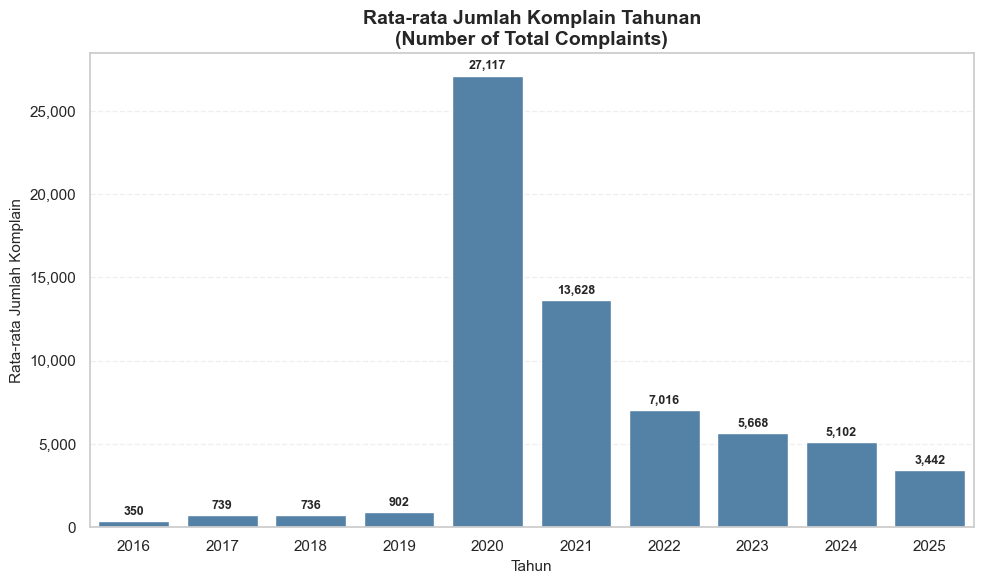

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Menggunakan tema seaborn
sns.set_theme(style="whitegrid")

fig1, ax1 = plt.subplots(figsize=(10, 6))

# Hitung rata-rata komplain per tahun
avg_complaints = df.groupby('Year')['Number of Total Complaints'].mean().reset_index()
avg_complaints.columns = ['Year', 'Avg_Complaints']

# Bar chart menggunakan seaborn
sns.barplot(
    data=avg_complaints,
    x='Year',
    y='Avg_Complaints',
    color='steelblue',
    ax=ax1
)

# Tambahkan label nilai di atas setiap bar
for i, val in enumerate(avg_complaints['Avg_Complaints']):
    ax1.text(
        i,
        val + 200,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Pengaturan tampilan
ax1.set_title(
    'Rata-rata Jumlah Komplain Tahunan\n(Number of Total Complaints)',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata Jumlah Komplain', fontsize=11)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax1.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

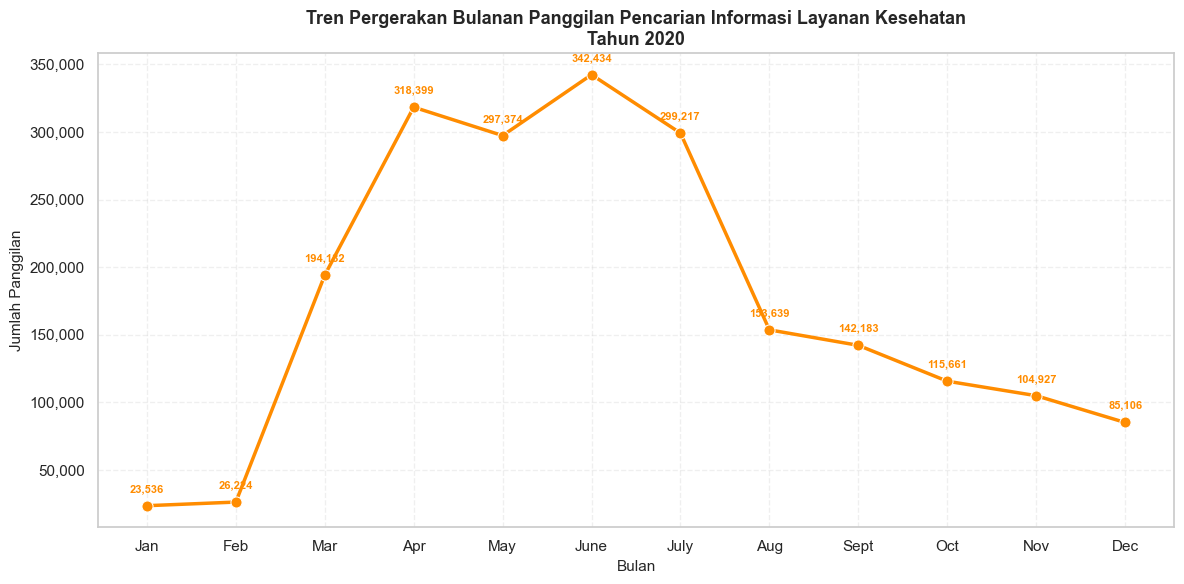

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Tema seaborn
sns.set_theme(style="whitegrid")

fig2, ax2 = plt.subplots(figsize=(12, 6))

# Filter hanya tahun 2020 dan urutkan berdasarkan bulan
df_2020 = df[df['Year'] == 2020].sort_values('Month')

# Line chart menggunakan seaborn
sns.lineplot(
    data=df_2020,
    x='Month',
    y='Number of Calls To Know About The Service',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='darkorange',
    ax=ax2
)

# Tambahkan label nilai di setiap titik
for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (row['Month'], row['Number of Calls To Know About The Service']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=8,
        color='darkorange',
        fontweight='bold'
    )

# Pengaturan tampilan
ax2.set_title(
    'Tren Pergerakan Bulanan Panggilan Pencarian Informasi Layanan Kesehatan\nTahun 2020',
    fontsize=13,
    fontweight='bold'
)

ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Jumlah Panggilan', fontsize=11)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

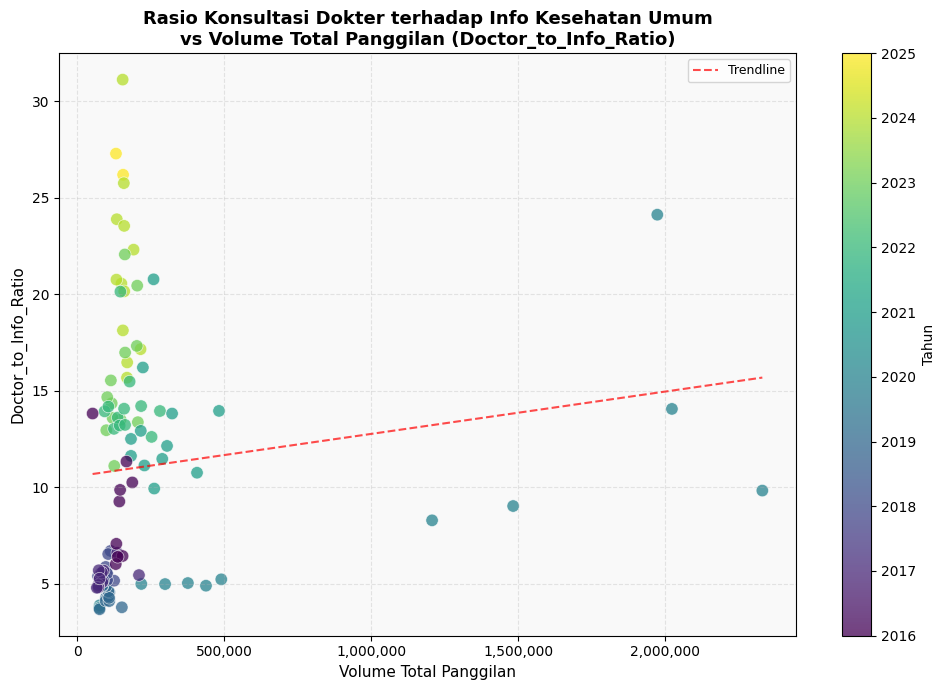

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Tema seaborn
sns.set_theme(style="whitegrid")

fig3, ax3 = plt.subplots(figsize=(10, 7))

# Buat kolom rasio
df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy']
    / df['Number of Total Health Information']
)

# Scatterplot menggunakan seaborn
scatter = sns.scatterplot(
    data=df,
    x='Total Number of Calls',
    y='Doctor_to_Info_Ratio',
    hue='Year',
    palette='viridis',
    s=80,
    alpha=0.75,
    edgecolor='white',
    linewidth=0.5,
    ax=ax3
)

# Trendline
z = np.polyfit(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df['Total Number of Calls'].min(),
    df['Total Number of Calls'].max(),
    200
)

ax3.plot(
    x_line,
    p(x_line),
    'r--',
    linewidth=1.5,
    alpha=0.7,
    label='Trendline'
)

# Judul dan label
ax3.set_title(
    'Rasio Konsultasi Dokter terhadap Info Kesehatan Umum\n'
    'vs Volume Total Panggilan (Doctor_to_Info_Ratio)',
    fontsize=13,
    fontweight='bold'
)

ax3.set_xlabel('Volume Total Panggilan', fontsize=11)
ax3.set_ylabel('Doctor_to_Info_Ratio', fontsize=11)

# Format angka sumbu X
ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax3.grid(alpha=0.3, linestyle='--')

# Legend
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\imman\AppData\Local\Temp\ipykernel_34764\4239076813.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


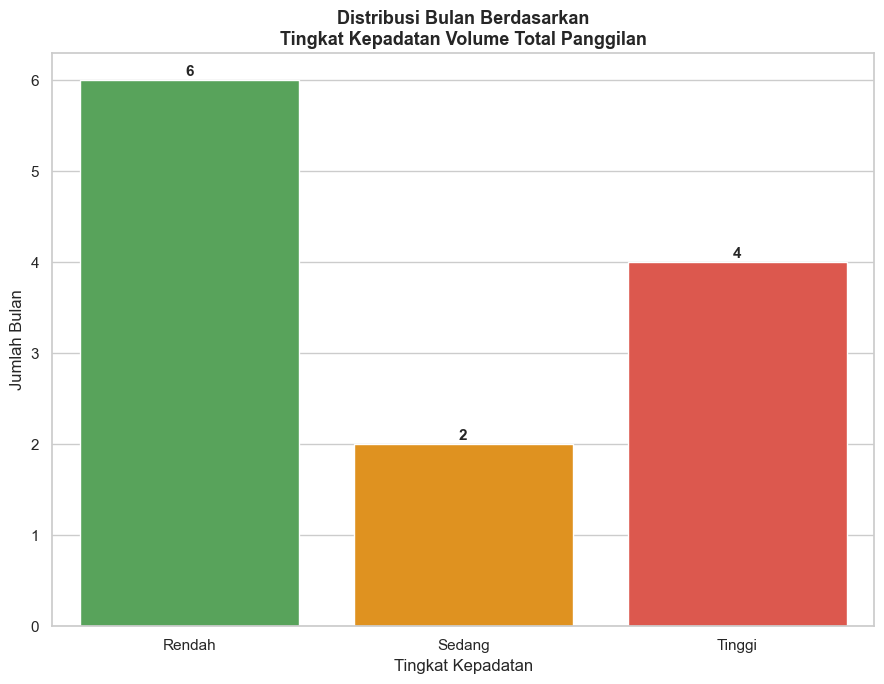

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig4, ax4 = plt.subplots(figsize=(9, 7))

# Hitung total panggilan per bulan
monthly_total = df.groupby(
    'Month',
    observed=True
)['Total Number of Calls'].sum().reset_index()

monthly_total.columns = ['Month', 'Total_Calls']

# Kelompokkan menjadi 3 kategori
monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Hitung jumlah bulan per kategori
density_count = (
    monthly_total['Density_Level']
    .value_counts()
    .reindex(['Rendah', 'Sedang', 'Tinggi'])
    .reset_index()
)

density_count.columns = ['Density_Level', 'Jumlah_Bulan']

# Barplot Seaborn
sns.barplot(
    data=density_count,
    x='Density_Level',
    y='Jumlah_Bulan',
    palette=['#4CAF50', '#FF9800', '#F44336'],
    ax=ax4
)

# Label angka di atas bar
for i, val in enumerate(density_count['Jumlah_Bulan']):
    ax4.text(
        i,
        val + 0.05,
        str(val),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax4.set_title(
    'Distribusi Bulan Berdasarkan\n'
    'Tingkat Kepadatan Volume Total Panggilan',
    fontsize=13,
    fontweight='bold'
)

ax4.set_xlabel('Tingkat Kepadatan')
ax4.set_ylabel('Jumlah Bulan')

plt.tight_layout()
plt.show()

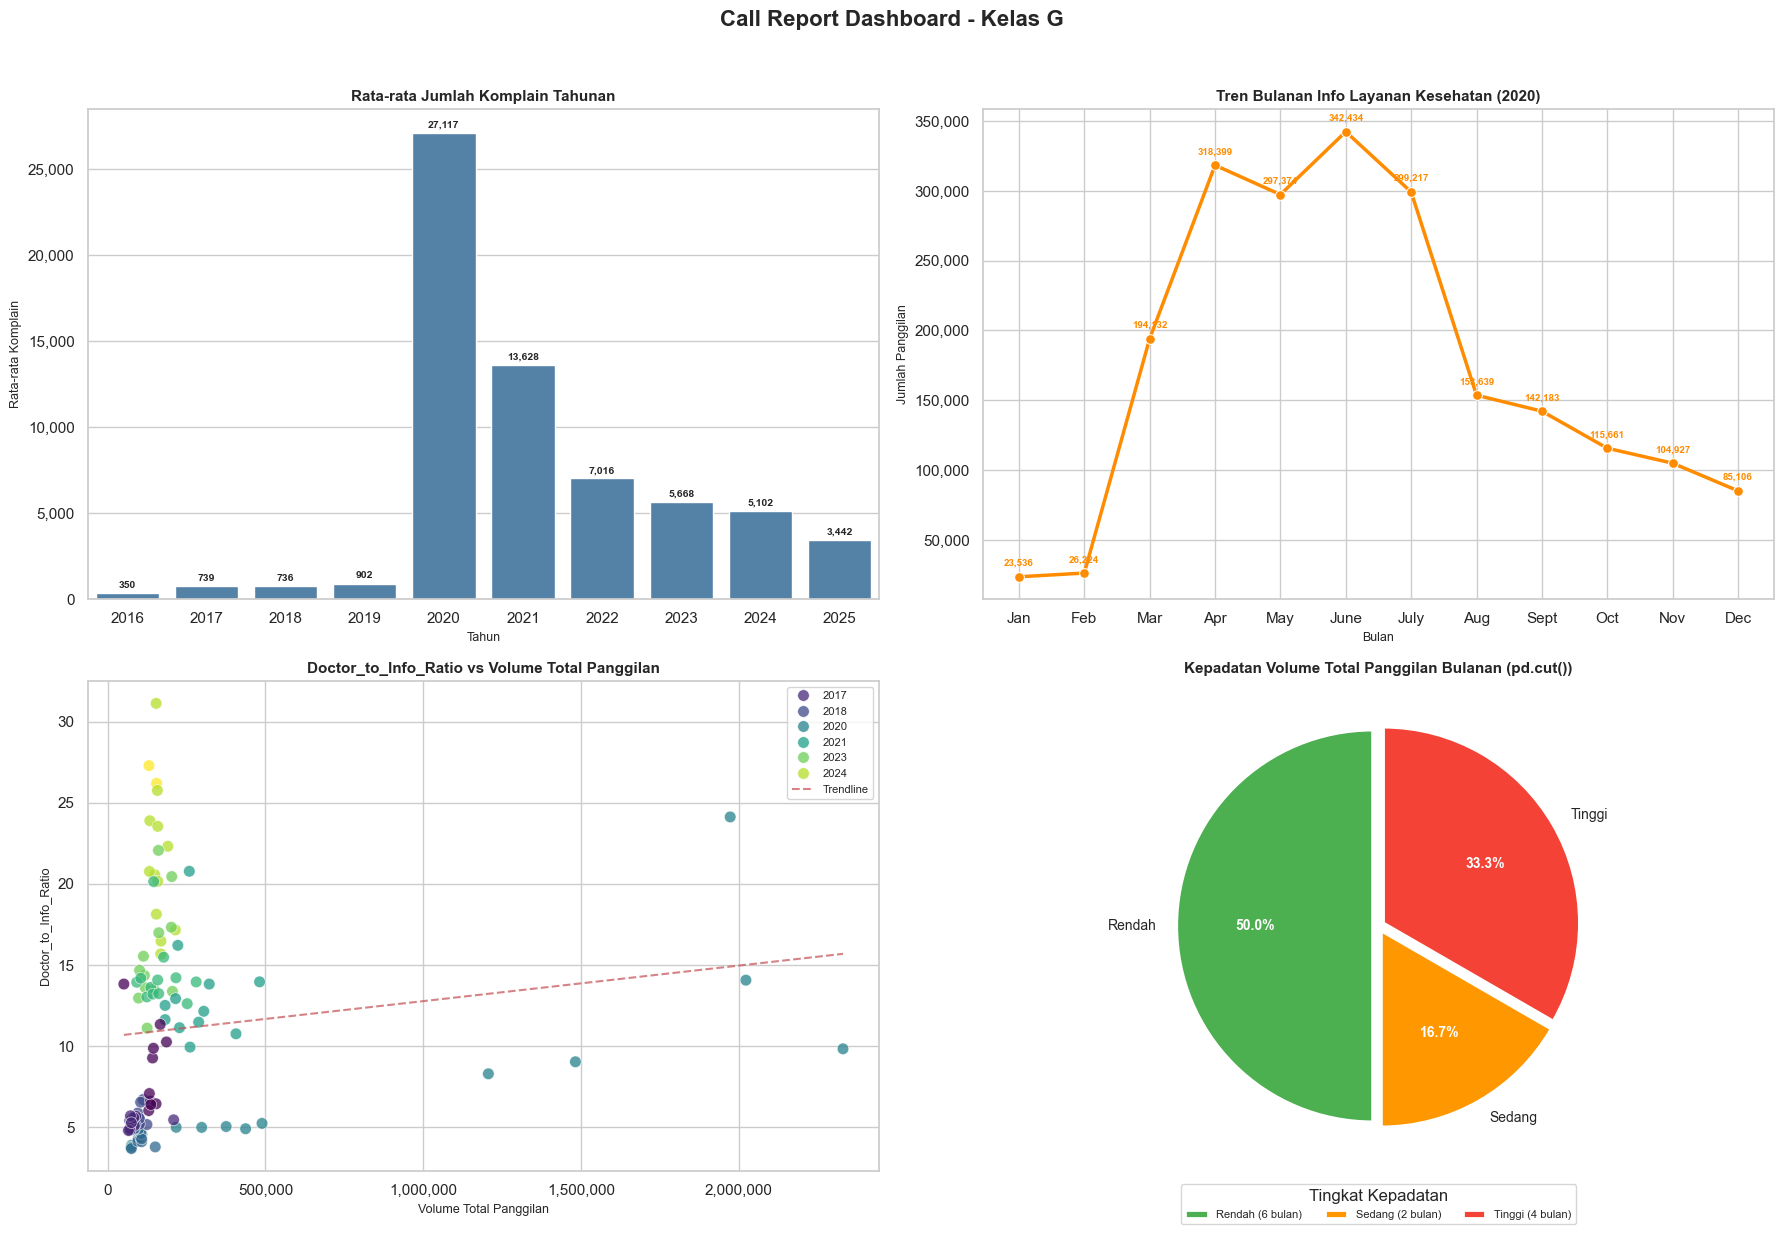

✅ Grafik gabungan 2x2 selesai! Tersimpan sebagai grafik5_gabungan_2x2.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
    'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

# Tema Seaborn
sns.set_theme(style="whitegrid")

# ============================================================
# GABUNGAN 4 GRAFIK — Grid 2x2
# ============================================================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.suptitle(
    'Call Report Dashboard - Kelas G',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# ============================================================
# SOAL 1
# Visualisasi Agregasi (Seaborn Barplot)
# ============================================================
avg_complaints = (
    df.groupby('Year')['Number of Total Complaints']
    .mean()
    .reset_index()
)

avg_complaints.columns = ['Year', 'Avg_Complaints']

sns.barplot(
    data=avg_complaints,
    x='Year',
    y='Avg_Complaints',
    color='steelblue',
    ax=ax1
)

for i, val in enumerate(avg_complaints['Avg_Complaints']):
    ax1.text(
        i,
        val + 200,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold'
    )

ax1.set_title(
    'Rata-rata Jumlah Komplain Tahunan',
    fontsize=11,
    fontweight='bold'
)

ax1.set_xlabel('Tahun', fontsize=9)
ax1.set_ylabel('Rata-rata Komplain', fontsize=9)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# ============================================================
# SOAL 2
# Visualisasi Tren (Seaborn Lineplot)
# ============================================================
df_2020 = (
    df[df['Year'] == 2020]
    .sort_values('Month')
)

sns.lineplot(
    data=df_2020,
    x='Month',
    y='Number of Calls To Know About The Service',
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='darkorange',
    ax=ax2
)

for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (
            row['Month'],
            row['Number of Calls To Know About The Service']
        ),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=7,
        color='darkorange',
        fontweight='bold'
    )

ax2.set_title(
    'Tren Bulanan Info Layanan Kesehatan (2020)',
    fontsize=11,
    fontweight='bold'
)

ax2.set_xlabel('Bulan', fontsize=9)
ax2.set_ylabel('Jumlah Panggilan', fontsize=9)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# ============================================================
# SOAL 3
# Visualisasi Korelasi (Seaborn Scatterplot)
# ============================================================
df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy']
    / df['Number of Total Health Information']
)

sns.scatterplot(
    data=df,
    x='Total Number of Calls',
    y='Doctor_to_Info_Ratio',
    hue='Year',
    palette='viridis',
    s=70,
    alpha=0.75,
    edgecolor='white',
    linewidth=0.5,
    ax=ax3
)

# Trendline
z = np.polyfit(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df['Total Number of Calls'].min(),
    df['Total Number of Calls'].max(),
    200
)

ax3.plot(
    x_line,
    p(x_line),
    'r--',
    linewidth=1.5,
    alpha=0.7,
    label='Trendline'
)

ax3.legend(fontsize=8)

ax3.set_title(
    'Doctor_to_Info_Ratio vs Volume Total Panggilan',
    fontsize=11,
    fontweight='bold'
)

ax3.set_xlabel(
    'Volume Total Panggilan',
    fontsize=9
)

ax3.set_ylabel(
    'Doctor_to_Info_Ratio',
    fontsize=9
)

ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# ============================================================
# SOAL 4
# Visualisasi Distribusi (Pie Chart)
# ============================================================
monthly_total = (
    df.groupby(
        'Month',
        observed=True
    )['Total Number of Calls']
    .sum()
    .reset_index()
)

monthly_total.columns = [
    'Month',
    'Total_Calls'
]

monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=[
        'Rendah',
        'Sedang',
        'Tinggi'
    ]
)

density_count = (
    monthly_total['Density_Level']
    .value_counts()
    .reindex([
        'Rendah',
        'Sedang',
        'Tinggi'
    ])
)

colors = [
    '#4CAF50',
    '#FF9800',
    '#F44336'
]

wedges, texts, autotexts = ax4.pie(
    density_count,
    labels=density_count.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [
    f'{level} ({count} bulan)'
    for level, count
    in zip(
        density_count.index,
        density_count.values
    )
]

ax4.legend(
    wedges,
    legend_labels,
    title='Tingkat Kepadatan',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    fontsize=8
)

ax4.set_title(
    'Kepadatan Volume Total Panggilan Bulanan (pd.cut())',
    fontsize=11,
    fontweight='bold'
)

# ============================================================
# SIMPAN & TAMPILKAN
# ============================================================
plt.tight_layout()

plt.savefig(
    'grafik5_gabungan_2x2.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Grafik gabungan 2x2 selesai! "
    "Tersimpan sebagai grafik5_gabungan_2x2.png"
)